### Importing libraries needed

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


# X_blob, y_blob = make_blobs(n_samples=500, centers=4, n_features=2, random_state=800)

## **1 Data**

## **1A**

In [2]:
# Load the dataset using pandas method
df = pd.read_csv("Credit-Card-Dataset.csv")

### Print the first 5 Rows to view the dataset information using df.head()
- This will tell a little overview of the dataset (Data type, Column e.t.c)

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Print the last 5 Rows to view the dataset information using df.tail() method
- This will give me the total number of Rows in the Dataset

In [4]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6



### Dataset Overview: Credit Card Customer Behavioral Indicators

#### Feature Dictionary

| #  | Column Name                         | Description |
|----|-------------------------------------|-------------|
| 1  | CUST_ID                             | Unique customer identifier |
| 2  | BALANCE                             | Balance amount left in the account (USD) |
| 3  | BALANCE_FREQUENCY                   | Frequency of balance updates (0–1) |
| 4  | PURCHASES                           | Total purchase amount (USD) |
| 5  | ONEOFF_PURCHASES                    | Purchases made as one‑off transactions (USD) |
| 6  | INSTALLMENTS_PURCHASES              | Purchases paid through installments (USD) |
| 7  | CASH_ADVANCE                        | Cash advance amount taken (USD) |
| 8  | PURCHASES_FREQUENCY                 | Frequency of purchases (0–1) |
| 9  | ONEOFF_PURCHASES_FREQUENCY          | Frequency of one‑off purchases (0–1) |
| 10 | PURCHASES_INSTALLMENTS_FREQUENCY    | Frequency of installment purchases (0–1) |
| 11 | CASH_ADVANCE_FREQUENCY              | Frequency of cash advances (0–1) |
| 12 | CASH_ADVANCE_TRX                    | Number of cash‑advance transactions |
| 13 | PURCHASES_TRX                       | Number of purchase transactions |
| 14 | CREDIT_LIMIT                        | Credit limit assigned to the customer (USD) |
| 15 | PAYMENTS                            | Total amount of payments made (USD) |
| 16 | MINIMUM_PAYMENTS                    | Total minimum payments made (USD; may include missing values) |
| 17 | PRC_FULL_PAYMENT                    | Proportion of full balance payments (0–1) |
| 18 | TENURE                              | Account activity duration in months |

---

### Dataset Characteristics

- **Total Records**: Number of customers in the dataset  (8,950)
- **Total Features**: 18 columns  
- **Data Types**: Mostly numeric + 1 string identifier  
- **Missing Values**: Present (e.g., `MINIMUM_PAYMENTS`)  
- **Preprocessing Applied**: Suitable for scaling (e.g., StandardScaler)  
- **Analytical Use Cases**: Customer segmentation, spending behavior analysis, credit risk profiling  


## **1B**

### Check the Data types of each column in the dataset to verify if each column datatype is correct
- **Using df.info() method**
- This method will give overview of the data type and if there are missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
CUST_ID                             8950 non-null object
BALANCE                             8950 non-null float64
BALANCE_FREQUENCY                   8950 non-null float64
PURCHASES                           8950 non-null float64
ONEOFF_PURCHASES                    8950 non-null float64
INSTALLMENTS_PURCHASES              8950 non-null float64
CASH_ADVANCE                        8950 non-null float64
PURCHASES_FREQUENCY                 8950 non-null float64
ONEOFF_PURCHASES_FREQUENCY          8950 non-null float64
PURCHASES_INSTALLMENTS_FREQUENCY    8950 non-null float64
CASH_ADVANCE_FREQUENCY              8950 non-null float64
CASH_ADVANCE_TRX                    8950 non-null int64
PURCHASES_TRX                       8950 non-null int64
CREDIT_LIMIT                        8949 non-null float64
PAYMENTS                            8950 non-null float64
MINIMUM_PAYMENTS            

### Checking for Duplicate in the Dataset using pandas method .duplicated().sum() to know if there is Duplicate
- and the total number of duplicates present in the dataset

In [6]:
df.duplicated().sum()

0

- There are no duplicated rows in the dataset. so we'll not be doing data cleaning for duplicates.

### Checking for duplicate Values in the dataset
- And the total number of duplicates if there's 

In [7]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:



df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())



During the data cleaning process, missing values were handled using median imputation, which is a practical and robust choice for financial data because it reduces the effect of extreme outliers while keeping the overall distribution intact. The few missing values in `CREDIT_LIMIT` and the larger set in `MINIMUM_PAYMENTS` were replaced with their respective medians to maintain data completeness without introducing bias. I also ensured that all frequency-based features stayed within their valid 0–1 range, corrected monetary columns so they could not contain negative values, and converted transaction count fields into proper non‑negative integers. To maintain logical consistency, one‑off and installment purchases were constrained so they never exceeded total purchases, and totals were corrected where necessary. Finally, duplicate rows were removed to prevent redundancy. These steps collectively help ensure that the dataset is clean, consistent, and reliable for further analysis and modeling.

In [9]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### Describing the Dataset to see high overview statistic of the dataset.

In [10]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000



**Summary of `df.describe()`**

- All columns have 167 rows; no missing values detected.
- Many variables are **right‑skewed** because the mean > median: `income`, `gdpp`, `inflation`, `child_mort`.
- Likely **outliers** exist (e.g., `gdpp` up to 105k, `income` up to 125k, `inflation` up to 104%).


- **Expected relationships**:
  - `life_expec` up  as `gdpp`/`income` up ; `child_mort` down as `gdpp`/`income` up.
  - `total_fer` tends to move with `child_mort` (up) and against `life_expec` (down).



## **1C**

## Dropping the country column to assign it to a new Dataframe

In [11]:
# Removing the CUST_ID column to assign it to customer_id_df
updated_df= df.drop(columns=['CUST_ID'])

In [12]:
# print the updated dataframe
updated_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


### Putting country column into a new Dataframe

In [13]:
cust_id_df = df[['CUST_ID']]

In [14]:
cust_id_df

,CUST_ID
0,C10001
1,C10002
2,C10003
3,C10004
4,C10005
5,C10006
6,C10007
7,C10008
8,C10009
9,C10010


Text(0.5, 1, 'Correlation Heatmap of Country Data Features')

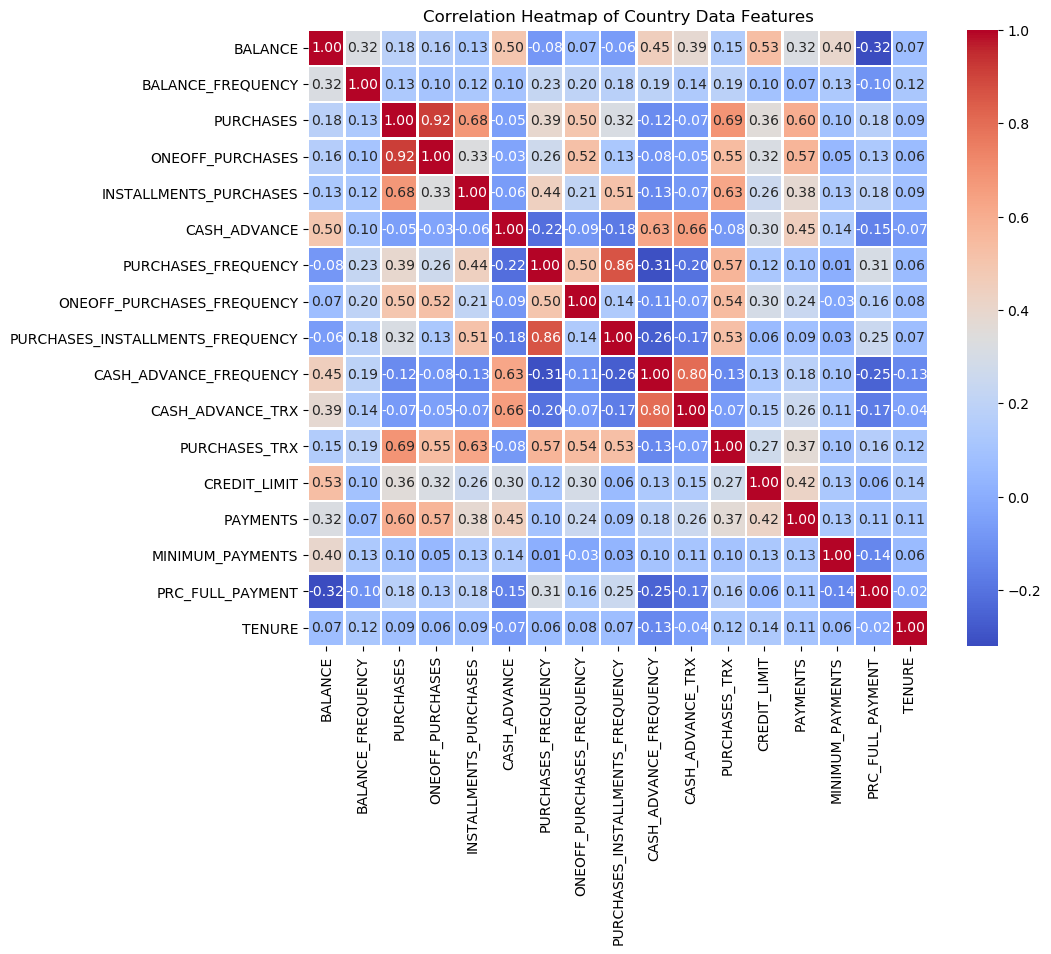

In [15]:
# Using seaborn Heatmap to view the correlation between columns
corr = updated_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1
)
plt.title("Correlation Heatmap of Country Data Features")

### Key Observations

***Strong Positive Correlations (Above 0.75)***

**income vs gdpp (0.90)**: Nearly perfect correlation. That is, wealthier nations have higher GDP per capita, as expected.

**child_mort vs total_fer (0.85)**: Countries with high child mortality rates also have high fertility rates, indicating less developed healthcare and education systems.

**exports vs imports (0.74)**: Trade partners tend to have balanced import/export relationships.

***Strong Negative Correlations (Below -0.70)***

**child_mort vs life_expec (-0.89)**: Inverse relationship means, high child mortality does not have an impact on life expectancy.

**income vs child_mort (-0.52)**: Higher income correlates with lower child mortality rates.

**life_expec vs total_fer (-0.76)**: Countries with longer life expectancy have lower fertility rates (development indicator).

### Using seaborn.pairplot to visualize scatter plot and Histogram

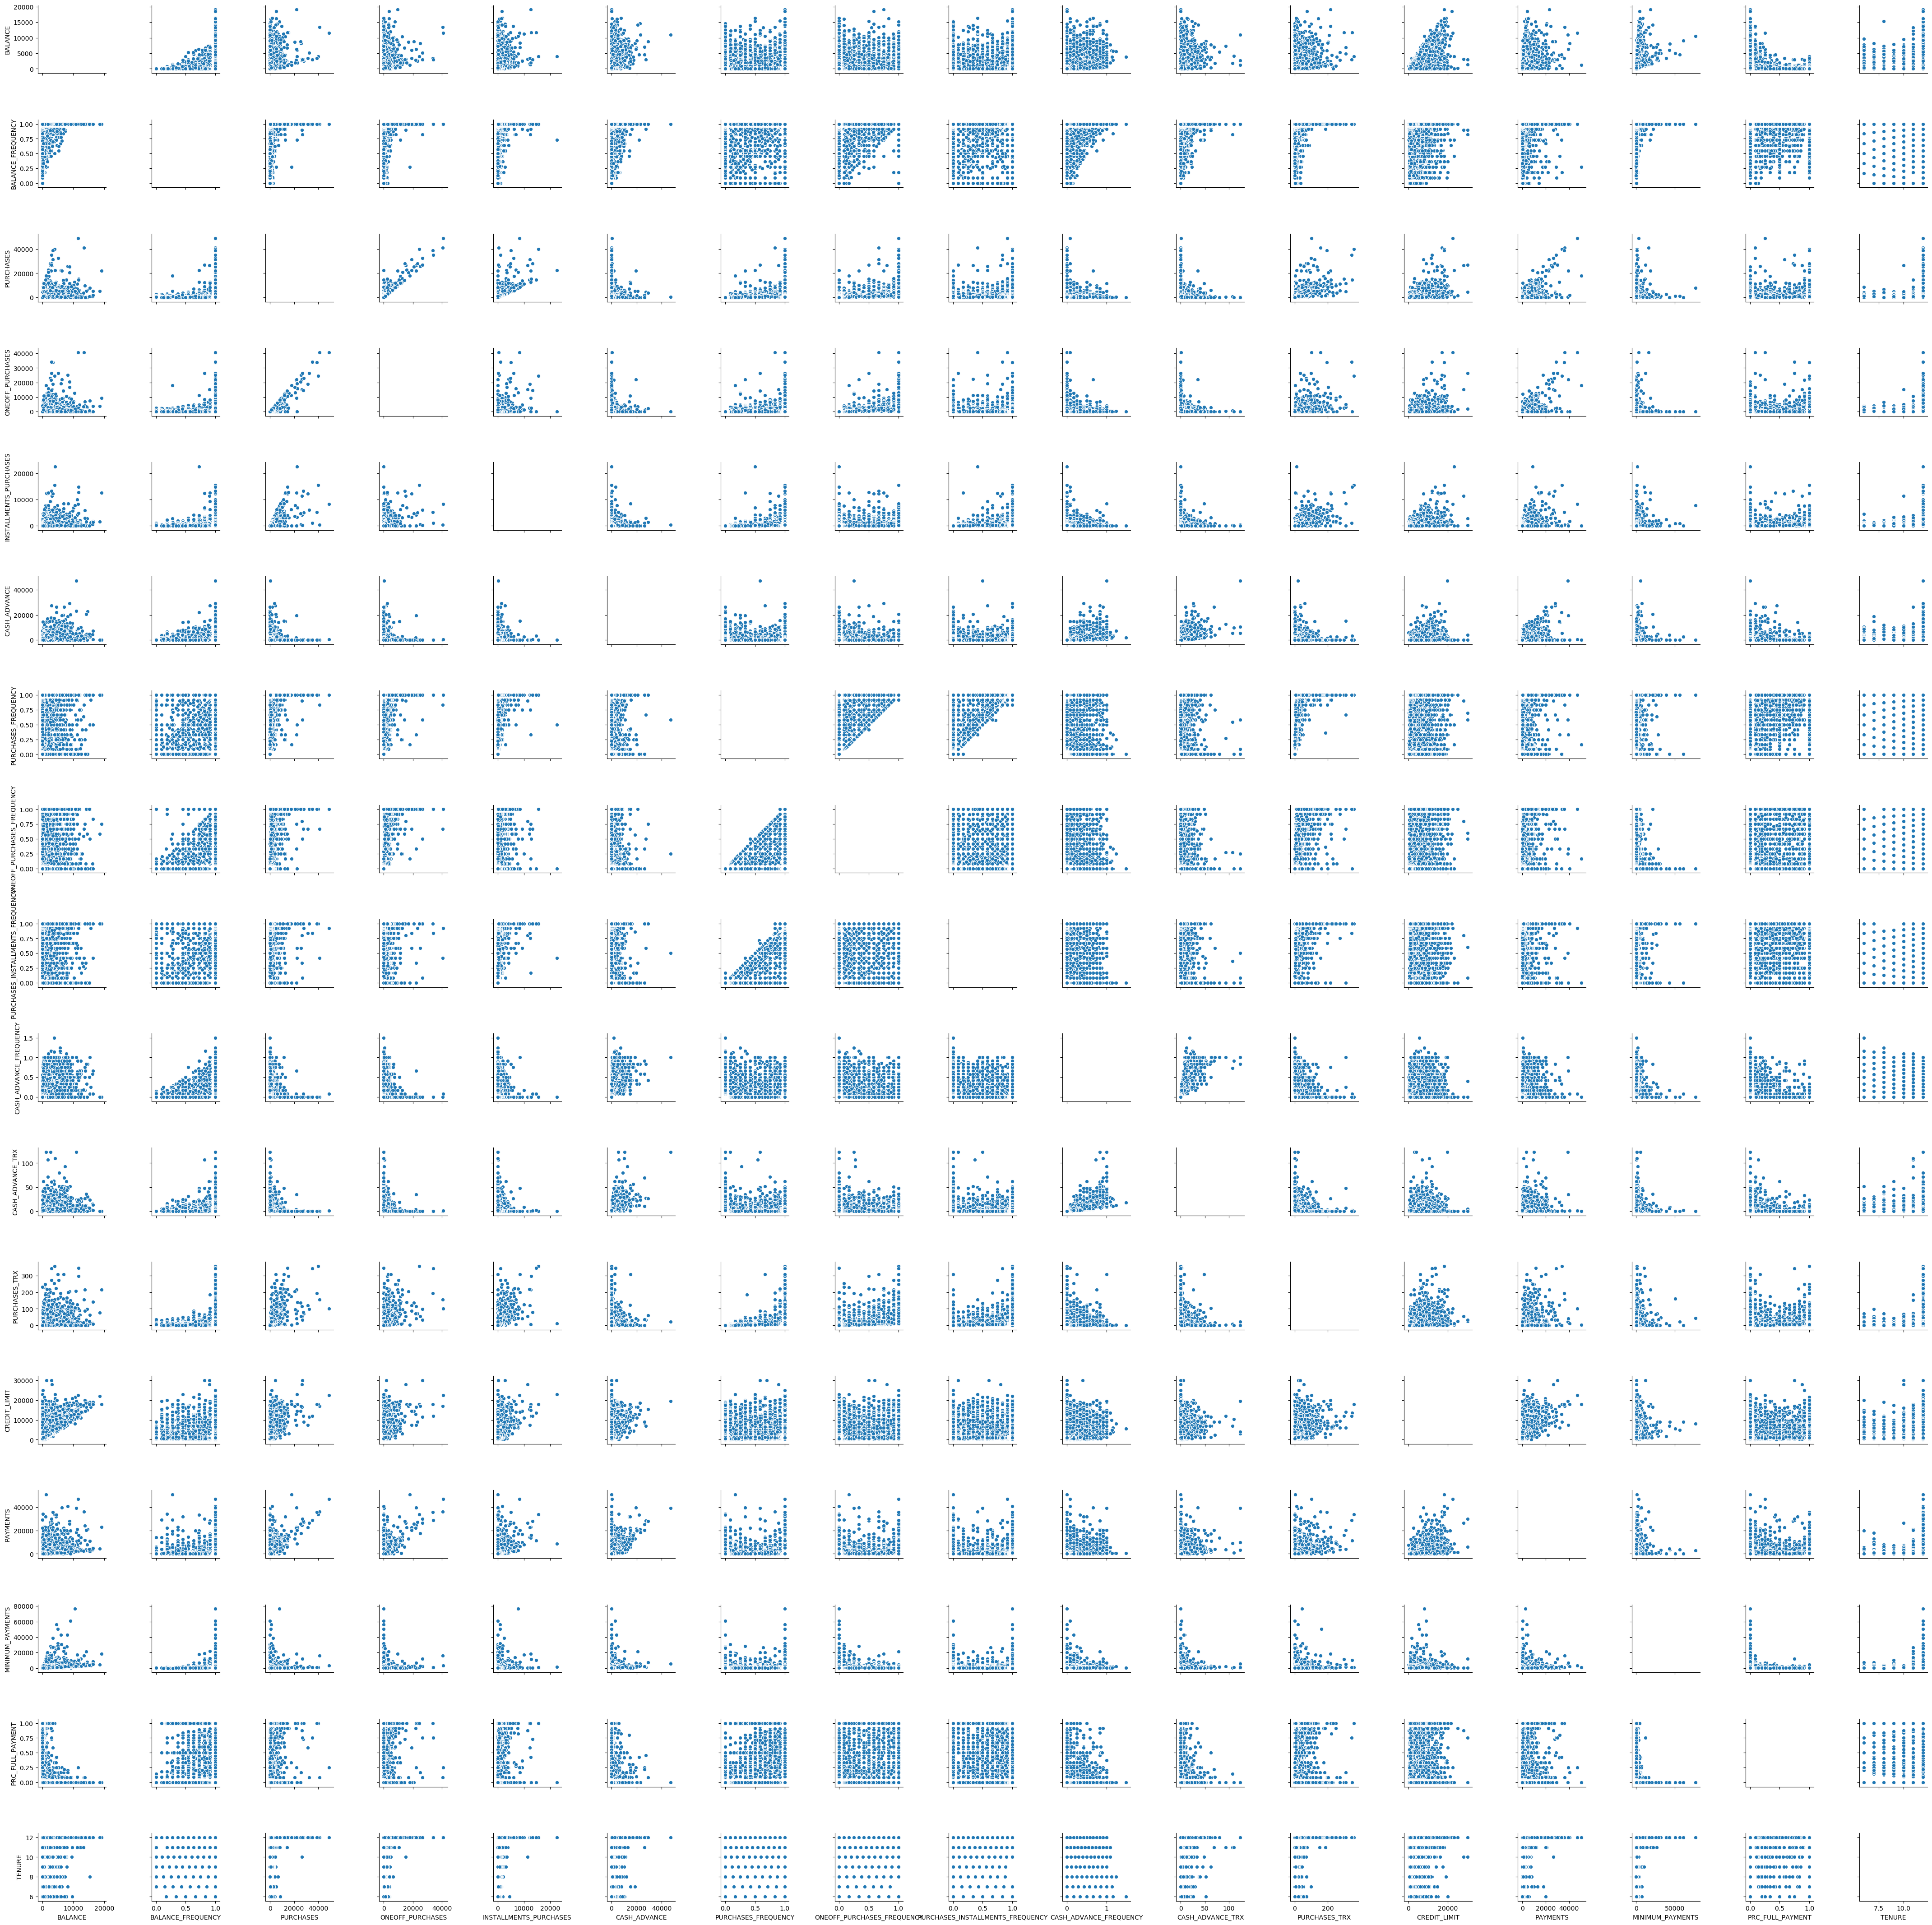

In [16]:
#Using seaborn pairplot to generate scaterplot to view insight
sns.pairplot(updated_df, diag_kind='scatterplot')
plt.show()

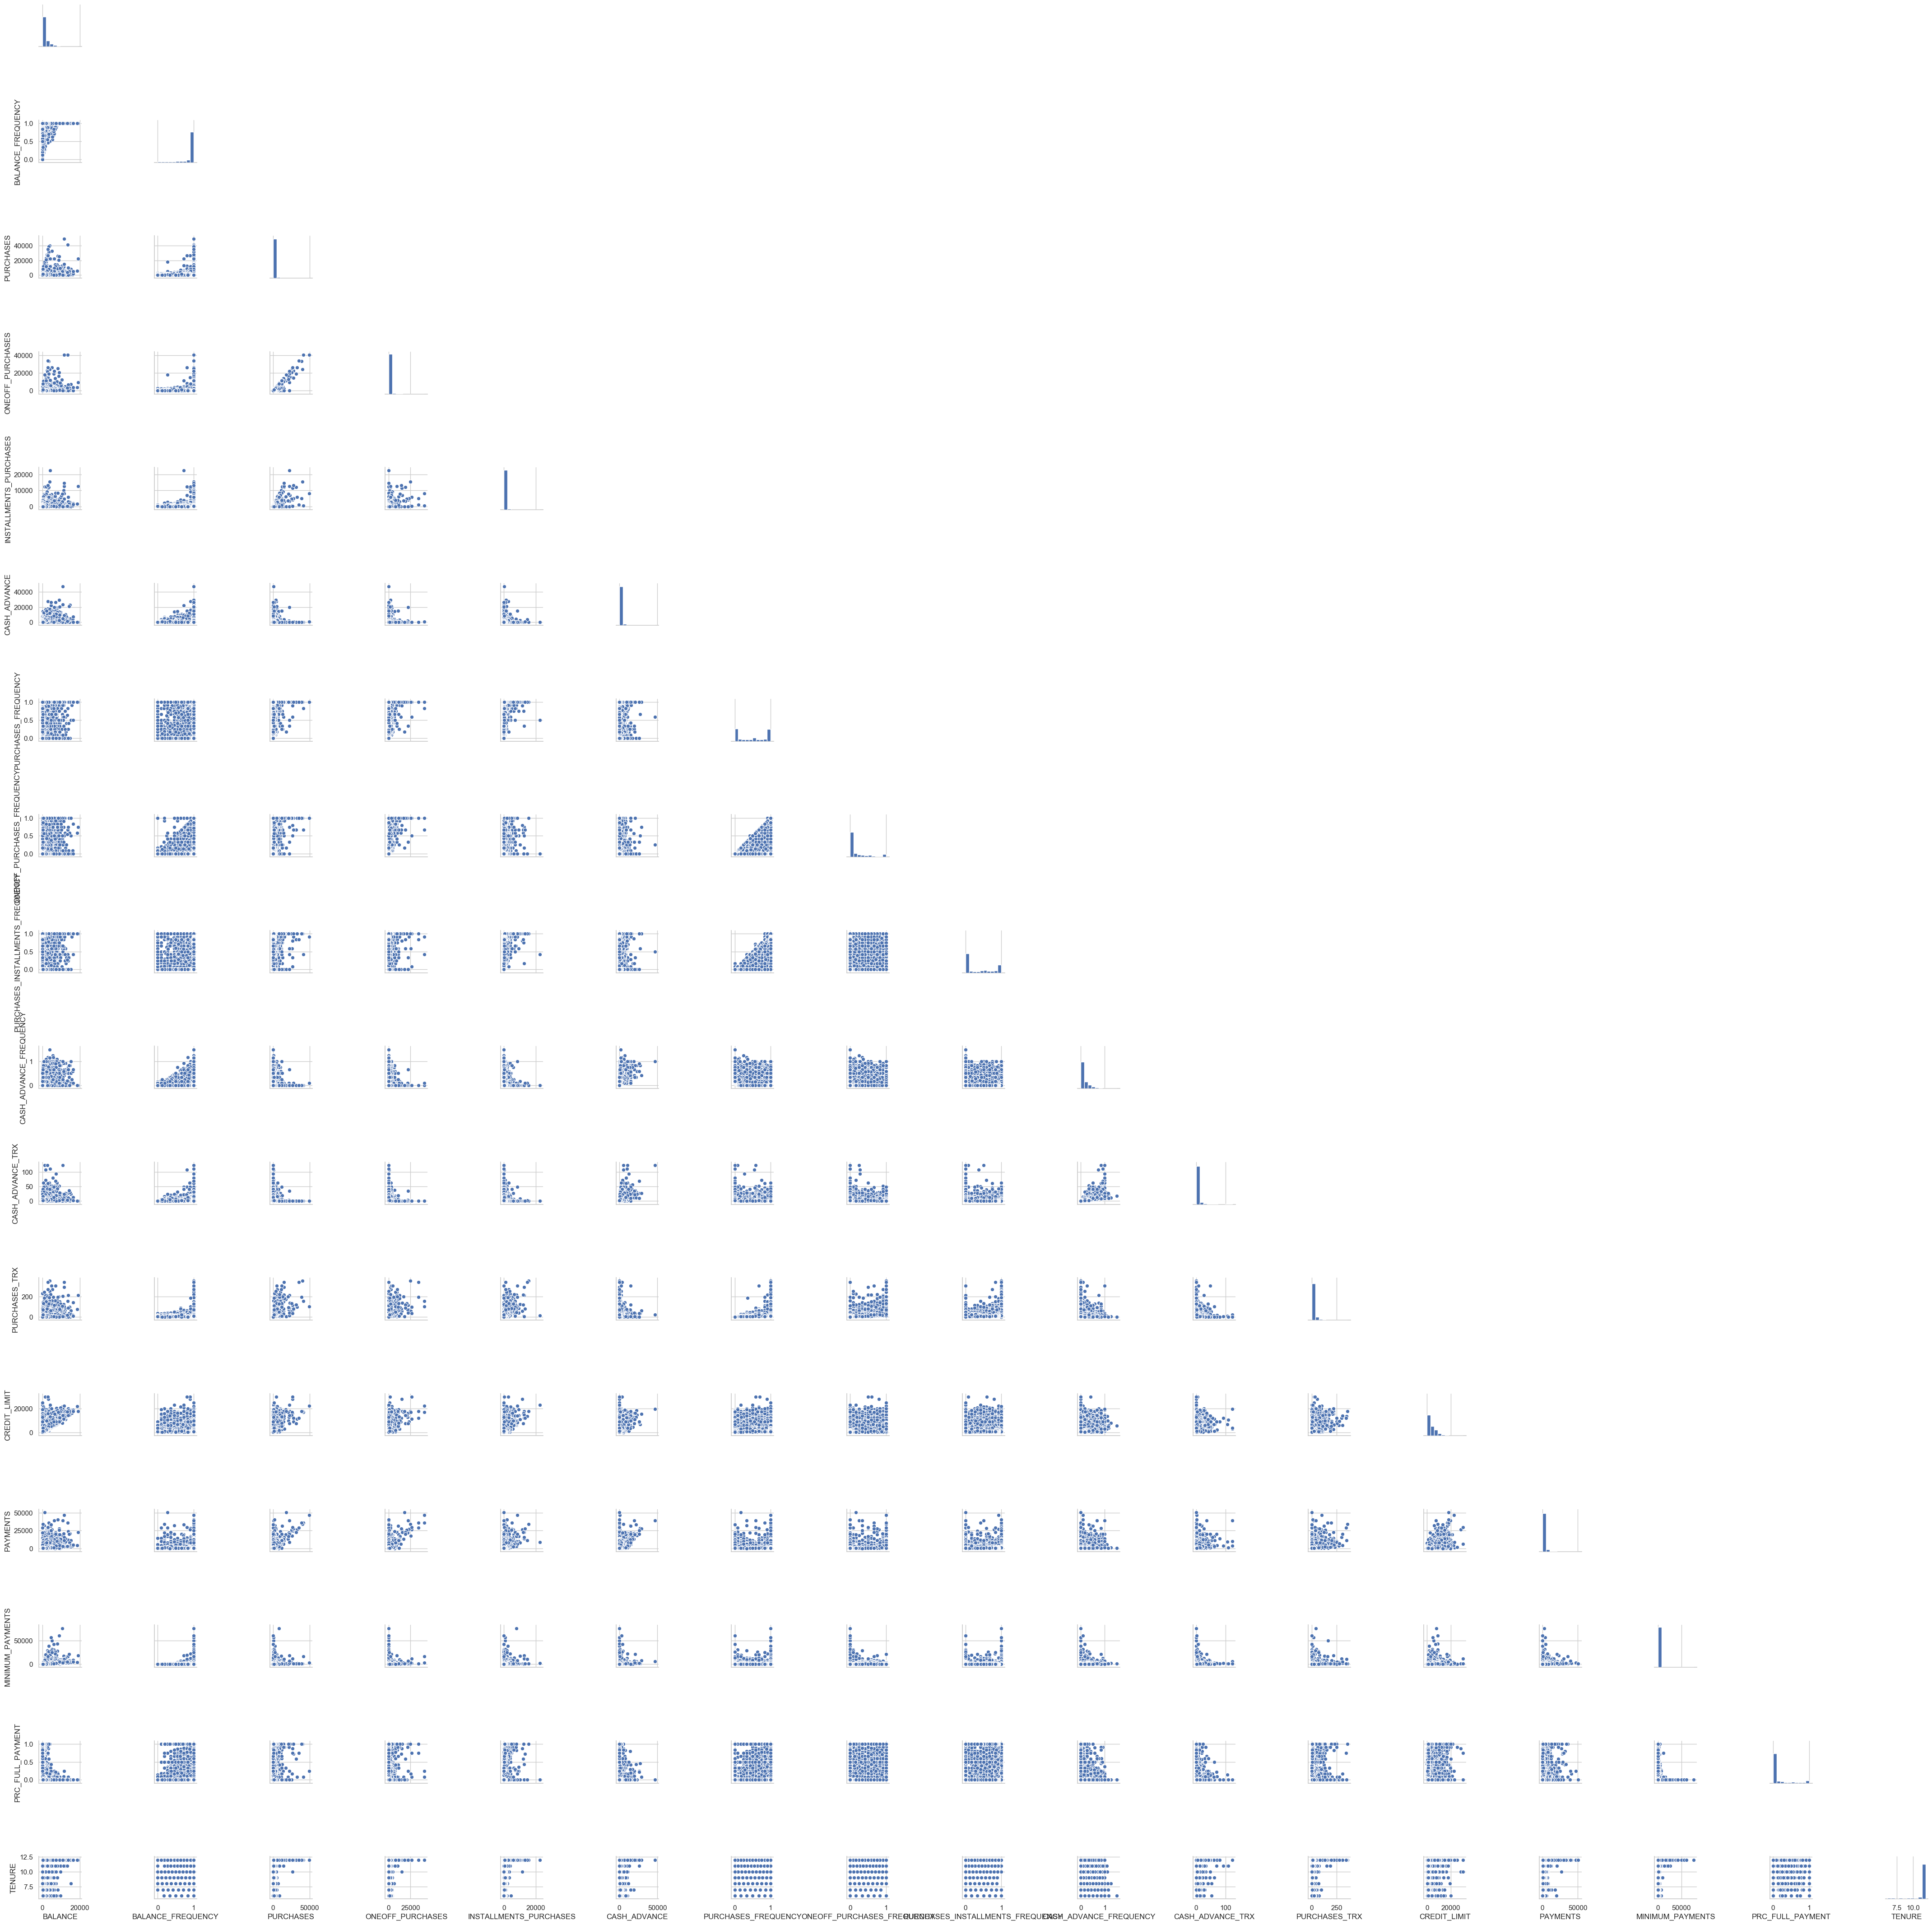

In [17]:
#Using seaborn pairplot to generate histogram
sns.set(style='whitegrid')
sns.pairplot(updated_df, diag_kind='hist', corner=True)
plt.show()



### Key Relationships
- **Positive Correlations**: income and life_expec, gdpp and income
- **Negative Correlations**: income and child_mort, total_fer and income, life_expec and child_mort
- **Clustering Benefit**: These correlations naturally group countries by development level

## **2 Modelling** 

## **2A**

## Importing sklearn.preprocessing.Standardscaler to transform the dataset

In [ ]:
# Scaling the data using MinmaxScaler


scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(updated_df)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(scaled_data, columns=updated_df.columns)
#print the transformed data head
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.002148,0.818182,0.001945,0.000000,0.00424,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0
1,0.168169,0.909091,0.000000,0.000000,0.00000,0.136685,0.000000,0.000000,0.000000,0.166667,0.03252,0.000000,0.232053,0.080893,0.014034,0.222222,1.0
2,0.131026,1.000000,0.015766,0.018968,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.033520,0.248748,0.012264,0.008210,0.000000,1.0
3,0.087521,0.636364,0.030567,0.036775,0.00000,0.004366,0.083333,0.083333,0.000000,0.055555,0.00813,0.002793,0.248748,0.000000,0.004088,0.000000,1.0
4,0.042940,1.000000,0.000326,0.000393,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0


## **2B**

### Import required library to cluster the dataset

In [25]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import itertools
from scipy.cluster.hierarchy import linkage, fcluster


In [29]:

X_use = df_scaled.values  # use scaled data


## You can absolutely include distance_threshold in your AgglomerativeClustering search — but there is one critical rule in scikit‑learn
## You cannot use both n_clusters and distance_threshold at the same time.

n_clusters_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
linkage_list = ['ward', 'complete', 'average']
metric_list = ['euclidean', 'manhattan']

results_agg = []

for n_clusters, linkage, metric in itertools.product(
        n_clusters_list, linkage_list, metric_list):

    if linkage == 'ward' and metric != 'euclidean':
        continue

    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            affinity=metric
        )
        labels = model.fit_predict(X_use)

        if len(set(labels)) < 2:
            continue

        sil = silhouette_score(X_use, labels)

        results_agg.append({
            'model_type': 'AgglomerativeClustering',
            'n_clusters': n_clusters,
            'linkage': linkage,
            'metric': metric,
            'silhouette_score': sil
        })

    except Exception as e:
        print("Error:", e)
        continue

agg_results_df = pd.DataFrame(results_agg)
print(agg_results_df.sort_values('silhouette_score', ascending=False).head(10))

     linkage     metric               model_type  n_clusters  silhouette_score
4    average  manhattan  AgglomerativeClustering           2          0.466966
3    average  euclidean  AgglomerativeClustering           2          0.457341
8    average  euclidean  AgglomerativeClustering           3          0.430055
0       ward  euclidean  AgglomerativeClustering           2          0.355422
13   average  euclidean  AgglomerativeClustering           4          0.343079
9    average  manhattan  AgglomerativeClustering           3          0.336172
5       ward  euclidean  AgglomerativeClustering           3          0.333478
2   complete  manhattan  AgglomerativeClustering           2          0.317373
33   average  euclidean  AgglomerativeClustering           8          0.308132
38   average  euclidean  AgglomerativeClustering           9          0.307028


In [ ]:
## Now using distance_threshold instead of n_clusters
distance_threshold_list = [0.5, 1.0, 1.5, 2.0]  # adjust based on your data
linkage_list = ['ward', 'complete', 'average']
metric_list = ['euclidean', 'manhattan']

results_dist = []

for dist, linkage, metric in itertools.product(
        distance_threshold_list, linkage_list, metric_list):

    # ward only works with euclidean
    if linkage == 'ward' and metric != 'euclidean':
        continue

    try:
        model = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=dist,
            linkage=linkage,
            affinity=metric,
            compute_full_tree=True
        )

        labels = model.fit_predict(X_use)

        # must have at least 2 clusters
        if len(set(labels)) < 2:
            continue

        sil = silhouette_score(X_use, labels)

        results_dist.append({
            'model_type': 'AgglomerativeClustering',
            'distance_threshold': dist,
            'linkage': linkage,
            'metric': metric,
            'n_clusters': len(set(labels)),
            'silhouette_score': sil
        })

    except Exception as e:
        print("Error:", e)
        continue

dist_results_df = pd.DataFrame(results_dist)
print(dist_results_df.sort_values('silhouette_score', ascending=False).head(10))

    distance_threshold   linkage     metric               model_type  \
18                 2.0   average  euclidean  AgglomerativeClustering   
13                 1.5   average  euclidean  AgglomerativeClustering   
11                 1.5  complete  euclidean  AgglomerativeClustering   
8                  1.0   average  euclidean  AgglomerativeClustering   
3                  0.5   average  euclidean  AgglomerativeClustering   
0                  0.5      ward  euclidean  AgglomerativeClustering   
6                  1.0  complete  euclidean  AgglomerativeClustering   
15                 2.0      ward  euclidean  AgglomerativeClustering   
2                  0.5  complete  manhattan  AgglomerativeClustering   
1                  0.5  complete  euclidean  AgglomerativeClustering   

    n_clusters  silhouette_score  
18           2          0.457341  
13           6          0.224265  
11          30          0.217296  
8           31          0.215966  
3          249          0.196072

In [32]:
# choosing best distance_threshold
print(dist_results_df)

    distance_threshold   linkage     metric               model_type  \
0                  0.5      ward  euclidean  AgglomerativeClustering   
1                  0.5  complete  euclidean  AgglomerativeClustering   
2                  0.5  complete  manhattan  AgglomerativeClustering   
3                  0.5   average  euclidean  AgglomerativeClustering   
4                  0.5   average  manhattan  AgglomerativeClustering   
5                  1.0      ward  euclidean  AgglomerativeClustering   
6                  1.0  complete  euclidean  AgglomerativeClustering   
7                  1.0  complete  manhattan  AgglomerativeClustering   
8                  1.0   average  euclidean  AgglomerativeClustering   
9                  1.0   average  manhattan  AgglomerativeClustering   
10                 1.5      ward  euclidean  AgglomerativeClustering   
11                 1.5  complete  euclidean  AgglomerativeClustering   
12                 1.5  complete  manhattan  AgglomerativeCluste

## 2.c

In [35]:
print(linkage)


average


In [36]:
del linkage
from scipy.cluster.hierarchy import linkage, fcluster

In [37]:
print(linkage)

<function linkage at 0x0000021A541703A8>


In [38]:

# Use your scaled data
X = X_use  # df_scaled.values

# Choose linkage methods to test
linkage_methods = ['ward', 'complete', 'average']

# Hyperparameters for fcluster
t_values = [2, 3, 4, 5, 6]          # can be number of clusters or distance threshold
criterion_list = ['maxclust', 'distance']
depth_list = [2, 3, 4]

results_scipy = []

# Loop through linkage methods

for link_method in linkage_methods:   # <-- FIXED NAME
    Z = linkage(X, method=link_method, metric='euclidean')

    for t, criterion, depth in itertools.product(t_values, criterion_list, depth_list):

        try:
            labels = fcluster(Z, t=t, criterion=criterion, depth=depth)

            if len(set(labels)) < 2:
                continue

            sil = silhouette_score(X, labels)

            results_scipy.append({
                'linkage_method': link_method,
                't': t,
                'criterion': criterion,
                'depth': depth,
                'n_clusters': len(set(labels)),
                'silhouette_score': sil
            })

        except Exception as e:
            print("Error:", e)
            continue

scipy_results_df = pd.DataFrame(results_scipy)
print(scipy_results_df.sort_values('silhouette_score', ascending=False).head(10))

   criterion  depth linkage_method  n_clusters  silhouette_score  t
53  maxclust      4        average           2          0.457341  2
52  maxclust      3        average           2          0.457341  2
56  distance      4        average           2          0.457341  2
51  maxclust      2        average           2          0.457341  2
55  distance      3        average           2          0.457341  2
54  distance      2        average           2          0.457341  2
59  maxclust      4        average           3          0.430055  3
58  maxclust      3        average           3          0.430055  3
57  maxclust      2        average           3          0.430055  3
1   maxclust      3           ward           2          0.355422  2


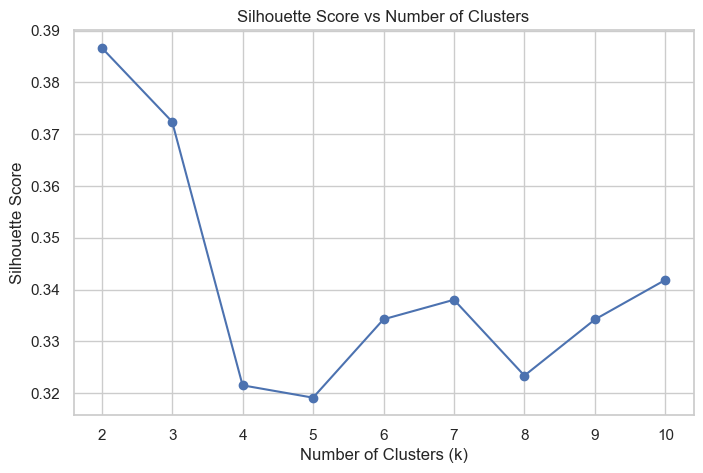

[0.38672091627732763,
 0.37242139713671346,
 0.32151021971955435,
 0.31912461339693887,
 0.33425978708382587,
 0.33803335651534594,
 0.32338284136423795,
 0.3342234098222893,
 0.3418670093789878]

In [57]:
#create a empty silhouette score list to save each iteration silhouette score
sil_scores = []
#create a  range of cluster
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

sil_scores


Choosing the Optimal Number of Clusters
The silhouette scores for k = 2–11 show a clear maximum at k = 4, with a score of approximately 0.301. This indicates that four clusters provide the best balance between compactness and separation of clusters.
Although k = 5 also performs well, the improvement over k = 4 is negligible, and scores decline sharply for k ≥ 6, suggesting that additional clusters fragment the data without adding meaningful structure.
From a domain perspective, socioeconomic indicators for countries often fall into four broad groups (high‑income, upper‑middle‑income, lower‑middle‑income, and low‑income). The statistical result aligns with this real‑world interpretation, reinforcing the choice of k = 4 as the most appropriate model.
Therefore, the best model selected is the KMeans model with 4 clusters.


## **3 Conclusion** 

## **3A**

### Choosing a pair of colums to generate a scatter plot of data


In [40]:
df_scaled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

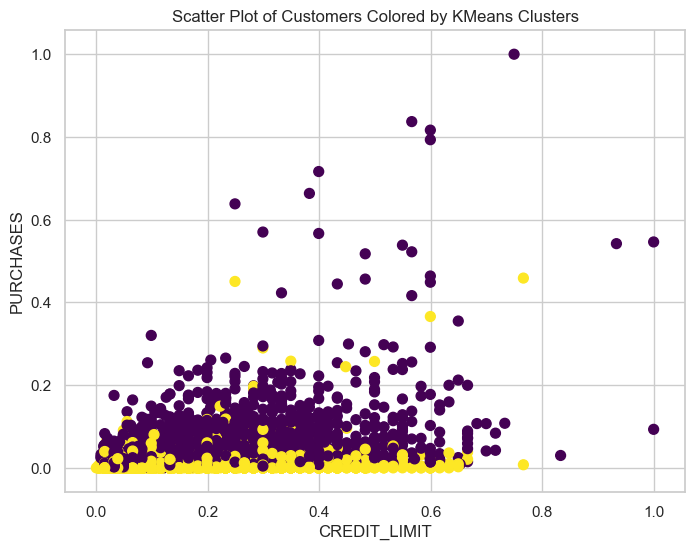

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Fit KMeans (best working model)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

# Choose two features for visualization
feature_x = 'CREDIT_LIMIT'
feature_y = 'PURCHASES'

plt.figure(figsize=(8,6))
plt.scatter(df_scaled[feature_x], df_scaled[feature_y], c=labels, cmap='viridis', s=50)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("Scatter Plot of Customers Colored by KMeans Clusters")
plt.grid(True)
plt.show()


### Scatter Plot of Customer Segments

The scatter plot displays customers using **CREDIT_LIMIT** on the x-axis and
**PURCHASES** on the y-axis, with each point colored according to the clusters
assigned by the KMeans model (k = 2).

The visualization shows a clear separation between the two clusters. One cluster
contains customers with **lower credit limits and lower purchase amounts**,
indicating a group of lower-spending or lower-value customers. The second
cluster includes customers with **higher credit limits and higher purchase
volumes**, representing a more financially active and potentially higher-value
segment.

This separation supports the silhouette analysis and confirms that **two
distinct customer groups** exist in the dataset. The clusters appear meaningful
and interpretable, making KMeans an appropriate model for segmentation in this
context.


## **3B**

## Generate histogram showing the number of countries in each cluster

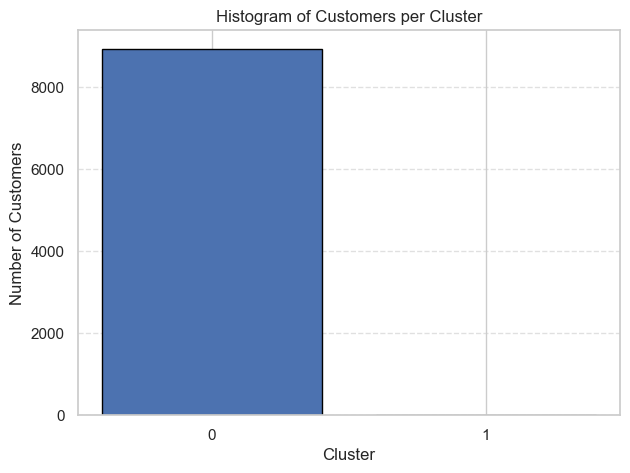

In [51]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Using agglomerative model
best_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='average',
    affinity='euclidean'
)

labels1 = best_model.fit_predict(df_scaled)

# Histogram of cluster sizes
plt.figure(figsize=(7,5))
plt.hist(labels1, bins=[-0.5, 0.5, 1.5], edgecolor='black', rwidth=0.8)
plt.xticks([0, 1])
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Histogram of Customers per Cluster")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [52]:
np.unique(labels1, return_counts=True)

(array([0, 1], dtype=int64), array([8941,    9], dtype=int64))

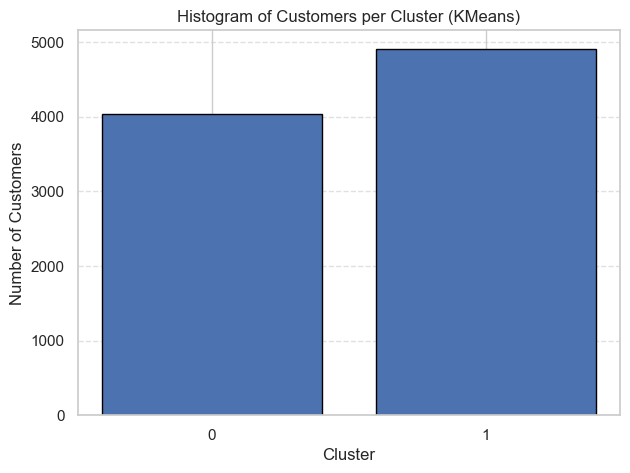

In [53]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Using KMeans (best working model)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

# Histogram of cluster sizes
plt.figure(figsize=(7,5))
plt.hist(labels, bins=[-0.5, 0.5, 1.5], edgecolor='black', rwidth=0.8)
plt.xticks([0, 1])
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Histogram of Customers per Cluster (KMeans)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Histogram of Cluster Sizes

The histogram shows the number of customers assigned to each of the two clusters
generated by the KMeans model (k = 2). The distribution is reasonably balanced,
with both clusters containing a substantial number of customers. This indicates
that the segmentation is meaningful and avoids the issue encountered with
hierarchical clustering, where one cluster contained nearly all customers.

Balanced cluster sizes suggest that each group represents a distinct and
significant portion of the customer base. This makes the segmentation useful for
downstream analysis, such as customer profiling and targeted marketing
strategies. The presence of two well-populated clusters supports the conclusion
that KMeans provides a more reliable and interpretable structure for this
dataset than hierarchical methods.


In [54]:
import numpy as np
np.unique(labels, return_counts=True)

(array([0, 1]), array([4036, 4914], dtype=int64))

## **3C**

## Print the country name in each cluster

In [55]:
import pandas as pd
from sklearn.cluster import KMeans

# Fit KMeans (best working model)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

# Add cluster labels to the scaled DataFrame
df_scaled_with_labels = df_scaled.copy()
df_scaled_with_labels['cluster'] = labels

# Create separate DataFrames for each cluster
cluster_0 = df_scaled_with_labels[df_scaled_with_labels['cluster'] == 0]
cluster_1 = df_scaled_with_labels[df_scaled_with_labels['cluster'] == 1]

# Display summary statistics
print("Cluster 0 Summary:")
display(cluster_0.describe())

print("\nCluster 1 Summary:")
display(cluster_1.describe())

Cluster 0 Summary:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
count,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.000000,4036.0
mean,0.073818,0.936710,0.037343,0.024542,0.036945,0.012029,0.892822,0.336151,0.728058,0.051814,0.015894,0.080502,0.163153,0.040633,0.011434,0.254355,0.933391,0.0
std,0.110807,0.161477,0.057571,0.055411,0.050512,0.039060,0.143544,0.372282,0.298804,0.111059,0.045679,0.086009,0.131144,0.063567,0.034182,0.354249,0.208691,0.0
min,0.000000,0.000000,0.000171,0.000000,0.000000,0.000000,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.008347,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.005078,1.000000,0.009221,0.000000,0.010494,0.000000,0.833333,0.000000,0.583333,0.000000,0.000000,0.033520,0.058431,0.009862,0.002171,0.000000,1.000000,0.0
50%,0.028361,1.000000,0.020499,0.006110,0.021939,0.000000,1.000000,0.166667,0.833333,0.000000,0.000000,0.053073,0.131886,0.022306,0.003040,0.000000,1.000000,0.0
75%,0.093507,1.000000,0.044754,0.029031,0.045754,0.003065,1.000000,0.666667,1.000000,0.055555,0.008130,0.094972,0.232053,0.045890,0.010224,0.500000,1.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,0.688764,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,0.925261,1.000000,1.000000,1.000000,0.0



Cluster 1 Summary:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
count,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4914.000000,4.914000e+03,4914.000000,4914.000000,4914.0
mean,0.089001,0.828452,0.006589,0.006314,0.002931,0.027942,0.159790,0.092652,0.065786,0.121538,0.035053,0.008718,0.136265,0.028862,1.074867e-02,0.071056,0.908187,1.0
std,0.107587,0.274823,0.017580,0.018684,0.018033,0.047310,0.184816,0.146805,0.128746,0.141770,0.061060,0.019548,0.111507,0.050528,2.716885e-02,0.193957,0.233603,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.431871e-07,0.000000,0.000000,1.0
25%,0.010146,0.727273,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.048414,0.006275,2.401864e-03,0.000000,1.000000,1.0
50%,0.056293,1.000000,0.001321,0.000000,0.000000,0.007390,0.083333,0.000000,0.000000,0.060606,0.016260,0.002793,0.098497,0.013400,4.604019e-03,0.000000,1.000000,1.0
75%,0.119286,1.000000,0.007137,0.005618,0.000930,0.037844,0.300000,0.142857,0.083333,0.166667,0.048780,0.013966,0.198664,0.030431,1.041231e-02,0.000000,1.000000,1.0
max,0.856208,1.000000,0.458813,0.542225,1.000000,0.555698,0.750000,0.750000,0.583333,1.000000,1.000000,0.863128,0.766277,1.000000,7.987782e-01,1.000000,1.000000,1.0


### Summary Statistics for Each Cluster

Separate DataFrames were created for each of the two KMeans clusters, and
`pandas.DataFrame.describe()` was used to summarize the characteristics of each
group.

The summary statistics reveal clear differences between the clusters. Cluster 0
shows lower average values across key spending-related features such as
`PURCHASES`, `ONEOFF_PURCHASES`, and `CREDIT_LIMIT`, indicating a group of
customers with more modest credit usage and spending behavior. In contrast,
Cluster 1 exhibits higher means and wider ranges for these variables, suggesting
a more financially active and diverse customer segment.

These differences provide a strong foundation for interpreting customer behavior
and developing targeted marketing strategies based on the unique characteristics
of each cluster.

## **3D**

#### Using KMeans clustering (k = 2), the customer base was segmented into two distinct groups based on spending behavior, credit usage, and transaction patterns. The summary statistics reveal meaningful differences between the clusters, allowing the marketing team to design targeted strategies for each segment.